# Policy Gradient Methods: REINFORCE and Actor-Critic

## Lab Objectives

In this lab, you will:
1. **Implement REINFORCE algorithm** - Monte Carlo policy gradient
2. **Implement Actor-Critic algorithm** - Hybrid policy gradient with value function
3. **Compare three methods** on **two environments**:
   - Your best **Double-DQN** from previous lab
   - **REINFORCE** (this lab)
   - **Actor-Critic** (this lab)
4. **Analyze results** on:
   - **CartPole-v1** (familiar environment)
   - **Acrobot-v1** (new challenging environment)

## What You'll Learn

- Direct policy optimization vs value-based methods
- The high variance problem in policy gradients
- How Actor-Critic reduces variance
- Comparative analysis of different RL algorithms

## Theoretical Background

### 1. Policy Gradient Theorem

**Objective**: Maximize expected cumulative reward

$$J(\theta) = \mathbb{E}_{\tau \sim \pi_\theta}[G_t] = \mathbb{E}_{\tau \sim \pi_\theta}\left[\sum_{t=0}^{T} \gamma^t r_t\right]$$

where $\tau = (s_0, a_0, r_0, s_1, \ldots)$ is a trajectory sampled from policy $\pi_\theta$.

**The Policy Gradient Theorem** provides a way to optimize policies directly:

$$\nabla_\theta J(\theta) = \mathbb{E}_{\tau \sim \pi_\theta}\left[\sum_{t=0}^{T} \nabla_\theta \log \pi_\theta(a_t|s_t) \cdot G_t\right]$$

**Key Insight**: We can estimate the gradient using samples!

1. Collect trajectories by running $\pi_\theta$ in environment
2. Compute returns $G_t$ for each timestep
3. Compute gradient: $\nabla_\theta \log \pi_\theta(a_t|s_t) \cdot G_t$
4. Update: $\theta \leftarrow \theta + \alpha \nabla_\theta J(\theta)$

### 2. REINFORCE Algorithm

**REINFORCE** implements the policy gradient theorem directly:

1. Generate episode: $s_0, a_0, r_0, \ldots, s_T, a_T, r_T$
2. For each timestep $t$:
   - Compute return: $G_t = \sum_{k=t}^{T} \gamma^{k-t} r_k$
3. Compute loss: $L = -\sum_t \log \pi_\theta(a_t|s_t) \cdot G_t$
4. Backpropagate: $\theta \leftarrow \theta + \alpha \nabla_\theta L$

**Problem**: High variance! $G_t$ varies a lot between trajectories.

### 3. Actor-Critic: Reducing Variance

**The High Variance Problem**: REINFORCE uses Monte Carlo returns $G_t$:
- Must wait until episode ends
- $G_t = r_t + \gamma r_{t+1} + \gamma^2 r_{t+2} + \cdots$
- High variance: small changes in actions cause big changes in $G_t$

**Solution: Use a Value Function (Critic)**

Instead of full return $G_t$, use TD learning:
- Critic estimates $V(s; w)$
- TD error: $\delta_t = r_t + \gamma V(s_{t+1}) - V(s_t)$
- Use $\delta_t$ as \"advantage estimate\" for actor update

**Actor-Critic Architecture**:

1. **Actor**: Policy network $\pi(a|s; \theta)$ - selects actions
2. **Critic**: Value network $V(s; w)$ - estimates state value

**Update Rules**:

Critic: $w \leftarrow w - \alpha_w \cdot \nabla_w [\delta_t^2]$ where $\delta_t = r_t + \gamma V(s_{t+1}; w) - V(s_t; w)$

Actor: $\theta \leftarrow \theta + \alpha_\theta \cdot \nabla_\theta \log \pi_\theta(a_t|s_t) \cdot \delta_t$

**Why It Works**:
- Lower variance: $\delta_t$ is single-step TD error, not full return
- Faster learning: Update after every step
- Bias-variance trade-off favors Actor-Critic in practice

## Setup and Imports

In [161]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch import Tensor

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

from typing import Tuple, List

import random
from collections import deque
import os

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

## Networks

We provide the neural network architectures. Your focus will be on implementing the training algorithms.

### Policy Network (Actor)
- Input: state
- Hidden: 128 neurons with ReLU
- Output: action probabilities (softmax)

### Value Network (Critic)
- Input: state
- Hidden: 128 neurons with ReLU
- Output: scalar value estimate

In [162]:
class PolicyNetwork(nn.Module):
    """Policy Network (Actor) that outputs action probabilities."""
    
    def __init__(self, state_dim: int, action_dim: int, hidden_dim: int = 128):
        super(PolicyNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, action_dim)
        
    def forward(self, x: Tensor) -> Tensor:
        x = F.relu(self.fc1(x))
        x = F.softmax(self.fc2(x), dim=1)
        return x


class ValueNetwork(nn.Module):
    """Value Network (Critic) that estimates state value V(s)."""
    
    def __init__(self, state_dim: int, hidden_dim: int = 128):
        super(ValueNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)
        
    def forward(self, x: Tensor) -> Tensor:
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

## DDQN

In [163]:
class QNetwork(nn.Module):
    """Q-Network that estimates action values Q(s, a)."""

    def __init__(self, state_dim: int, action_dim: int, hidden_dim: int = 128):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, action_dim)
        
    def forward(self, x: Tensor) -> Tensor:
        x = F.relu(self.fc1(x))
        return self.fc2(x)

class ReplayBuffer:
    """Experience Replay buffer to store and sample transitions."""
    
    def __init__(self, capacity: int = 10000):
        self.buffer = deque(maxlen=capacity)
        
    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))
        
    def sample(self, batch_size: int):
        states, actions, rewards, next_states, dones = zip(*random.sample(self.buffer, batch_size))
        return np.array(states), np.array(actions), np.array(rewards), np.array(next_states), np.array(dones)
        
    def __len__(self):
        return len(self.buffer)

## Helper Functions

In [164]:
def select_action(policy: nn.Module, state: np.ndarray, device: str = 'cpu') -> Tuple[int, Tensor]:
    """
    Sample action from policy distribution.
    
    Args:
        policy: Policy network
        state: Current state
        device: Device to run on
        
    Returns:
        action: Sampled action (integer)
        log_prob: Log probability of the action
    """
    state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
    probs = policy(state_tensor)
    
    # Create categorical distribution and sample
    action_dist = torch.distributions.Categorical(probs)
    action = action_dist.sample()
    log_prob = action_dist.log_prob(action)
    
    return action.item(), log_prob


def compute_returns(rewards: List[float], gamma: float = 0.99) -> Tensor:
    """
    Compute discounted returns for each timestep.
    
    Args:
        rewards: List of rewards from an episode
        gamma: Discount factor
        
    Returns:
        returns: Tensor of discounted returns
    """
    returns = []
    G = 0
    
    # Compute returns backwards from the end
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)
    
    return torch.FloatTensor(returns)

## Task 1: REINFORCE Training Loop

Implement the REINFORCE algorithm.

**Algorithm**:
1. Collect a full trajectory (episode)
2. Compute returns G_t for each timestep using `compute_returns()`
3. Normalize returns for variance reduction
4. Compute loss: -Σ log π(a_t|s_t) * G_t
5. Backpropagate and update policy

**Important**:
- Returns should be normalized: `(returns - returns.mean()) / (returns.std() + 1e-8)`
- Loss is negative because we want to maximize, not minimize
- The episode collection loop is provided; focus on the update section

In [165]:
def train_reinforce(
    env: gym.Env,
    policy: nn.Module,
    num_episodes: int = 1000,
    lr: float = 0.01,
    gamma: float = 0.99,
    device: str = 'cpu'
) -> List[float]:
    """
    Train agent using REINFORCE algorithm.
    
    Args:
        env: Gymnasium environment
        policy: Policy network
        num_episodes: Number of training episodes
        lr: Learning rate
        gamma: Discount factor
        device: Device to run on
        
    Returns:
        episode_rewards: List of total rewards per episode
    """
    optimizer = optim.Adam(policy.parameters(), lr=lr)
    episode_rewards = []
    
    for episode in range(num_episodes):
        # Storage for episode data
        log_probs = []
        rewards = []
        
        # Collect trajectory
        state, _ = env.reset()
        done = False
        
        while not done:
            action, log_prob = select_action(policy, state, device)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            log_probs.append(log_prob)
            rewards.append(reward)
            
            state = next_state
        
        # TODO: Task 1 - Implement REINFORCE update
        
        # Step 1: Compute returns using the compute_returns function
        returns = compute_returns(rewards, gamma)
        
        # Step 2: Normalize returns for variance reduction
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)
        
        # Step 3: Compute policy loss
        # FORMULA: L = -Σ log π(a_t|s_t) * G_t
        policy_loss = []
        for log_prob, G in zip(log_probs, returns):
            policy_loss.append(-log_prob * G)
        
        policy_loss = torch.cat(policy_loss).sum()
        
        # Step 4: Backpropagate and update
        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()
        
        # END TODO
        
        # Store episode reward
        episode_rewards.append(sum(rewards))
        
        # Logging
        if episode % 50 == 0:
            avg_reward = np.mean(episode_rewards[-50:])
            print(f"Episode {episode:4d} | Avg Reward: {avg_reward:6.2f}")
    
    return episode_rewards

## Task 2: Actor-Critic Training Loop

Implement the Actor-Critic algorithm.

**Algorithm (per step)**:
1. Select action from actor policy
2. Observe reward and next state
3. Compute TD error: δ = r + γV(s') - V(s)
4. Update critic to minimize δ²
5. Update actor using: log π(a|s) * δ (detached)

**Important**:
- If episode is done, next_value = 0 (no future reward)
- TD error should be detached when used for actor update
- The step loop is provided; focus on the update section

In [166]:
def train_actor_critic(
    env: gym.Env,
    actor: nn.Module,
    critic: nn.Module,
    num_episodes: int = 1000,
    lr_actor: float = 0.001,
    lr_critic: float = 0.005,
    gamma: float = 0.99,
    device: str = 'cpu'
) -> List[float]:
    """
    Train agent using Actor-Critic algorithm.
    
    Args:
        env: Gymnasium environment
        actor: Policy network
        critic: Value network
        num_episodes: Number of training episodes
        lr_actor: Learning rate for actor
        lr_critic: Learning rate for critic
        gamma: Discount factor
        device: Device to run on
        
    Returns:
        episode_rewards: List of total rewards per episode
    """
    actor_optimizer = optim.Adam(actor.parameters(), lr=lr_actor)
    critic_optimizer = optim.Adam(critic.parameters(), lr=lr_critic)
    episode_rewards = []
    
    for episode in range(num_episodes):
        state, _ = env.reset()
        done = False
        episode_reward = 0
        
        while not done:
            # Select action using actor
            action, log_prob = select_action(actor, state, device)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            episode_reward += reward
            
            # TODO: Task 2 - Implement Actor-Critic updates
            
            # Step 1: Prepare state tensors for networks
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
            next_state_tensor = torch.FloatTensor(next_state).unsqueeze(0).to(device)
            
            # Step 2: Compute value estimates using critic
            value = critic(state_tensor)
            
            with torch.no_grad():
                if terminated:
                    next_value = torch.tensor([[0.0]]).to(device)
                else:
                    next_value = critic(next_state_tensor)

            # Step 3: Compute TD error (advantage estimate)
            # FORMULA: δ = r + γV(s') - V(s)
            td_error = reward + gamma * next_value - value
            
            # Step 4: Update critic to minimize TD error squared
            critic_loss = td_error ** 2
            critic_optimizer.zero_grad()
            critic_loss.backward()
            critic_optimizer.step()

            
            # Step 5: Update actor using policy gradient
            # CRITICAL: Use .detach() on td_error!
            actor_loss = -log_prob * td_error.detach()
            actor_optimizer.zero_grad()
            actor_loss.backward()
            actor_optimizer.step()

            # END TODO
            
            state = next_state
        
        # Store episode reward
        episode_rewards.append(episode_reward)
        
        # Logging
        if episode % 50 == 0:
            avg_reward = np.mean(episode_rewards[-50:])
            print(f"Episode {episode:4d} | Avg Reward: {avg_reward:6.2f}")
    
    return episode_rewards

## DDQN Training Loop

In [167]:
def train_ddqn(
    env: gym.Env,
    num_episodes: int = 1000,
    lr: float = 0.001,
    gamma: float = 0.99,
    batch_size: int = 64,
    eps_decay_steps: int = 10000,
    learning_freq: int = 4,
    target_update_freq: int = 1000,
    device: str = 'cpu'
) -> List[float]:
    """Train an agent using Double Deep Q-Network with step-based hyperparameters."""

    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n
    
    # Initialize Online and Target networks
    q_net = QNetwork(state_dim, action_dim).to(device)
    target_net = QNetwork(state_dim, action_dim).to(device)
    target_net.load_state_dict(q_net.state_dict())
    
    optimizer = optim.Adam(q_net.parameters(), lr=lr)
    replay_buffer = ReplayBuffer(10000)
    
    # Epsilon-greedy parameters
    epsilon = 1.0
    epsilon_min = 0.01
    
    # Calculate linear decay amount per step
    eps_decay_amount = (1.0 - epsilon_min) / eps_decay_steps
    
    global_step = 0
    episode_rewards = []
    
    for episode in range(num_episodes):
        state, _ = env.reset()
        done = False
        episode_reward = 0
        
        while not done:
            global_step += 1
            
            # Epsilon-greedy action selection
            if random.random() < epsilon:
                action = env.action_space.sample()
            else:
                state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
                with torch.no_grad():
                    action = q_net(state_tensor).argmax(dim=1).item()
                    
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            # CRITICAL FIX: Store 'terminated' instead of 'done' so we don't 
            # zero out the Q-value target on a time limit truncation!
            replay_buffer.push(state, action, reward, next_state, terminated)
            
            state = next_state
            episode_reward += reward
            
            # 1. Step-based Epsilon Decay
            if epsilon > epsilon_min:
                epsilon -= eps_decay_amount
            
            # 2. Step-based Learning Frequency
            if len(replay_buffer) > batch_size and global_step % learning_freq == 0:
                s, a, r, ns, d = replay_buffer.sample(batch_size)
                
                s_tensor = torch.FloatTensor(s).to(device)
                a_tensor = torch.LongTensor(a).unsqueeze(1).to(device)
                r_tensor = torch.FloatTensor(r).unsqueeze(1).to(device)
                ns_tensor = torch.FloatTensor(ns).to(device)
                d_tensor = torch.FloatTensor(d).unsqueeze(1).to(device)
                
                # Double DQN Logic
                with torch.no_grad():
                    next_actions = q_net(ns_tensor).argmax(1, keepdim=True)
                    next_q_values = target_net(ns_tensor).gather(1, next_actions)
                    target_q_values = r_tensor + gamma * next_q_values * (1 - d_tensor)
                
                current_q_values = q_net(s_tensor).gather(1, a_tensor)
                
                loss = F.mse_loss(current_q_values, target_q_values)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                
            # 3. Step-based Target Network Update
            if global_step % target_update_freq == 0:
                target_net.load_state_dict(q_net.state_dict())
                
        episode_rewards.append(episode_reward)
        
        # Logging
        if episode % 50 == 0:
            avg_reward = np.mean(episode_rewards[-50:])
            # Added global_step to the print statement so you can monitor progress
            print(f"DDQN Episode {episode:4d} | Steps: {global_step:6d} | Avg Reward: {avg_reward:6.2f} | Epsilon: {epsilon:.2f}")
            
    return episode_rewards

## Task 3: CartPole Experiments

**Objective**: Compare three methods on CartPole-v1:
1. Your best Double-DQN from previous lab
2. REINFORCE (train here)
3. Actor-Critic (train here)

**Instructions**:
1. Load your best DDQN results (episode rewards)
2. Train REINFORCE for 1000 episodes
3. Train Actor-Critic for 1000 episodes
4. Compare learning curves

**Questions to answer**:
- Which method converges fastest?
- Which has lowest variance?
- Which achieves best final performance?

In [168]:
# Setup
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Create CartPole environment
env_cartpole = gym.make('CartPole-v1', max_episode_steps=200)
state_dim = env_cartpole.observation_space.shape[0]
action_dim = env_cartpole.action_space.n
print(f"CartPole - State dim: {state_dim}, Action dim: {action_dim}")

Using device: cuda
CartPole - State dim: 4, Action dim: 2


In [169]:
# TODO: Task 3 - CartPole Experiments

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

env_cartpole.reset(seed=SEED)
env_cartpole.action_space.seed(SEED)

# Part 1: Load your best Double-DQN results
# Replace this with your actual DDQN results from previous lab
# ddqn_rewards = np.load('path_to_your_ddqn_results.npy').tolist()
# OR manually copy the list of rewards
# ddqn_rewards = [10, 15, 20, ...]  # Your DDQN episode rewards

# For now, we'll use a placeholder
# ddqn_rewards = None  # Replace with your DDQN results

# Part 1: Train DDQN on CartPole
print("\n" + "="*50)
print("Training DDQN on CartPole...")
print("="*50)

ddqn_rewards = train_ddqn(
    env=env_cartpole,
    num_episodes=1000,
    lr=0.001,
    gamma=0.99,
    batch_size=64,
    eps_decay_steps=10000,
    learning_freq=4,
    target_update_freq=1000,
    device=device
)

env_cartpole.reset(seed=SEED)
env_cartpole.action_space.seed(SEED)

# # Part 2: Train REINFORCE on CartPole
print("\n" + "="*50)
print("Training REINFORCE on CartPole...")
print("="*50)

reinforce_policy_cartpole = PolicyNetwork(state_dim, action_dim).to(device)
reinforce_rewards_cartpole = train_reinforce(
    env=env_cartpole,
    policy=reinforce_policy_cartpole,
    num_episodes=1000,
    lr=0.01,
    gamma=0.99,
    device=device
)

env_cartpole.reset(seed=SEED)
env_cartpole.action_space.seed(SEED)

# Part 3: Train Actor-Critic on CartPole
print("\n" + "="*50)
print("Training Actor-Critic on CartPole...")
print("="*50)

actor_cartpole = PolicyNetwork(state_dim, action_dim).to(device)
critic_cartpole = ValueNetwork(state_dim).to(device)
ac_rewards_cartpole = train_actor_critic(
    env=env_cartpole,
    actor=actor_cartpole,
    critic=critic_cartpole,
    num_episodes=1000,
    lr_actor=0.0003,
    lr_critic=0.001,
    gamma=0.99,
    device=device
)

print("\nCartPole training complete!")

os.makedirs('results', exist_ok=True)
np.save('results/ddqn_cartpole_rewards.npy', ddqn_rewards)
np.save('results/reinforce_cartpole_rewards.npy', reinforce_rewards_cartpole)
np.save('results/ac_cartpole_rewards.npy', ac_rewards_cartpole)


Training DDQN on CartPole...
DDQN Episode    0 | Steps:     29 | Avg Reward:  29.00 | Epsilon: 1.00
DDQN Episode   50 | Steps:   1051 | Avg Reward:  20.44 | Epsilon: 0.90
DDQN Episode  100 | Steps:   2043 | Avg Reward:  19.84 | Epsilon: 0.80
DDQN Episode  150 | Steps:   3241 | Avg Reward:  23.96 | Epsilon: 0.68
DDQN Episode  200 | Steps:   4447 | Avg Reward:  24.12 | Epsilon: 0.56
DDQN Episode  250 | Steps:   7476 | Avg Reward:  60.58 | Epsilon: 0.26
DDQN Episode  300 | Steps:  16574 | Avg Reward: 181.96 | Epsilon: 0.01
DDQN Episode  350 | Steps:  26170 | Avg Reward: 191.92 | Epsilon: 0.01
DDQN Episode  400 | Steps:  35149 | Avg Reward: 179.58 | Epsilon: 0.01
DDQN Episode  450 | Steps:  42209 | Avg Reward: 141.20 | Epsilon: 0.01
DDQN Episode  500 | Steps:  48242 | Avg Reward: 120.66 | Epsilon: 0.01
DDQN Episode  550 | Steps:  53866 | Avg Reward: 112.48 | Epsilon: 0.01
DDQN Episode  600 | Steps:  62658 | Avg Reward: 175.84 | Epsilon: 0.01
DDQN Episode  650 | Steps:  72310 | Avg Reward:

## Task 4: Acrobot Experiments

**Objective**: Compare three methods on Acrobot-v1:

**About Acrobot**:
- Two-link pendulum robot
- Goal: Swing up to reach target height
- State: 6 dimensions (angles, velocities)
- Actions: 3 (torque left, none, right)
- Reward: -1 per step until goal reached
- More challenging than CartPole!

**Instructions**:
1. Load your best DDQN results on Acrobot (or train new DDQN)
2. Train REINFORCE for 1000 episodes
3. Train Actor-Critic for 1000 episodes
4. Compare learning curves

**Questions to answer**:
- How do results compare to CartPole?
- Which method handles this harder environment best?
- Is Actor-Critic's advantage more pronounced here?

In [170]:
# Create Acrobot environment
env_acrobot = gym.make('Acrobot-v1', max_episode_steps=500)
state_dim_acrobot = env_acrobot.observation_space.shape[0]  # 6
action_dim_acrobot = env_acrobot.action_space.n  # 3
print(f"Acrobot - State dim: {state_dim_acrobot}, Action dim: {action_dim_acrobot}")
print(f"Max episode steps: 500")

Acrobot - State dim: 6, Action dim: 3
Max episode steps: 500


In [171]:
# TODO: Task 4 - Acrobot Experiments

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

env_acrobot.reset(seed=SEED)
env_acrobot.action_space.seed(SEED)

# Part 1: Load your best Double-DQN results on Acrobot
# ddqn_rewards_acrobot = None  # Replace with your DDQN results

# Part 2: Train REINFORCE on Acrobot
print("\n" + "="*50)
print("Training REINFORCE on Acrobot...")
print("="*50)

# reinforce_policy_acrobot = PolicyNetwork(state_dim_acrobot, action_dim_acrobot).to(device)
# reinforce_rewards_acrobot = train_reinforce(
#     env=env_acrobot,
#     policy=reinforce_policy_acrobot,
#     num_episodes=1000,
#     lr=0.01,
#     gamma=0.99,
#     device=device
# )

# Part 3: Train Actor-Critic on Acrobot
print("\n" + "="*50)
print("Training Actor-Critic on Acrobot...")
print("="*50)

# actor_acrobot = PolicyNetwork(state_dim_acrobot, action_dim_acrobot).to(device)
# critic_acrobot = ValueNetwork(state_dim_acrobot).to(device)
# ac_rewards_acrobot = train_actor_critic(
#     env=env_acrobot,
#     actor=actor_acrobot,
#     critic=critic_acrobot,
#     num_episodes=1000,
#     lr_actor=0.001,
#     lr_critic=0.005,
#     gamma=0.99,
#     device=device
# )

print("\nAcrobot training complete!")


Training REINFORCE on Acrobot...

Training Actor-Critic on Acrobot...

Acrobot training complete!


## Visualization Functions

In [176]:
def moving_average_with_variance(data: List[float], window_size: int = 50) -> Tuple:
    """
    Calculate moving average and variance.
    
    Returns:
        indices, means, [lower_bounds, upper_bounds]
    """
    if len(data) < window_size:
        return [], [], []
    
    indices = np.arange(window_size - 1, len(data))
    means = []
    upper_bounds = []
    lower_bounds = []
    
    for i in range(window_size - 1, len(data)):
        window = data[i - window_size + 1 : i + 1]
        mean_val = np.mean(window)
        std_val = np.std(window)
        means.append(mean_val)
        upper_bounds.append(mean_val + std_val)
        lower_bounds.append(mean_val - std_val)
    
    return indices, means, [lower_bounds, upper_bounds]


def plot_comparison(ddqn_rewards, reinforce_rewards, ac_rewards, env_name: str):
    """Plot comparison of three methods."""
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Plot DDQN if available
    if ddqn_rewards is not None:
        x_dqn, dqn_mean, dqn_var = moving_average_with_variance(ddqn_rewards, 50)
        ax.plot(x_dqn, dqn_mean, color='green', label='Double-DQN', alpha=0.8, linewidth=2)
        ax.fill_between(x_dqn, dqn_var[0], dqn_var[1], alpha=0.2, color='green')
    
    # Plot REINFORCE
    x_rf, rf_mean, rf_var = moving_average_with_variance(reinforce_rewards, 50)
    ax.plot(x_rf, rf_mean, color='blue', label='REINFORCE', alpha=0.8, linewidth=2)
    ax.fill_between(x_rf, rf_var[0], rf_var[1], alpha=0.2, color='blue')
    
    # Plot Actor-Critic
    x_ac, ac_mean, ac_var = moving_average_with_variance(ac_rewards, 50)
    ax.plot(x_ac, ac_mean, color='orange', label='Actor-Critic', alpha=0.8, linewidth=2)
    ax.fill_between(x_ac, ac_var[0], ac_var[1], alpha=0.2, color='orange')
    
    ax.set_xlabel('Episode', fontsize=12)
    ax.set_ylabel('Average Reward (50-episode window)', fontsize=12)
    ax.set_title(f'Algorithm Comparison on {env_name}', fontsize=14, fontweight='bold')
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.savefig(f'{env_name}_comparison.png')
    
    # Print statistics
    print(f"\nFinal Performance on {env_name} (last 100 episodes):")
    if ddqn_rewards is not None:
        print(f"Double-DQN:   {np.mean(ddqn_rewards[-100:]):7.2f} +/- {np.std(ddqn_rewards[-100:]):.2f}")
    print(f"REINFORCE:    {np.mean(reinforce_rewards[-100:]):7.2f} +/- {np.std(reinforce_rewards[-100:]):.2f}")
    print(f"Actor-Critic: {np.mean(ac_rewards[-100:]):7.2f} +/- {np.std(ac_rewards[-100:]):.2f}")

## Results: CartPole Comparison

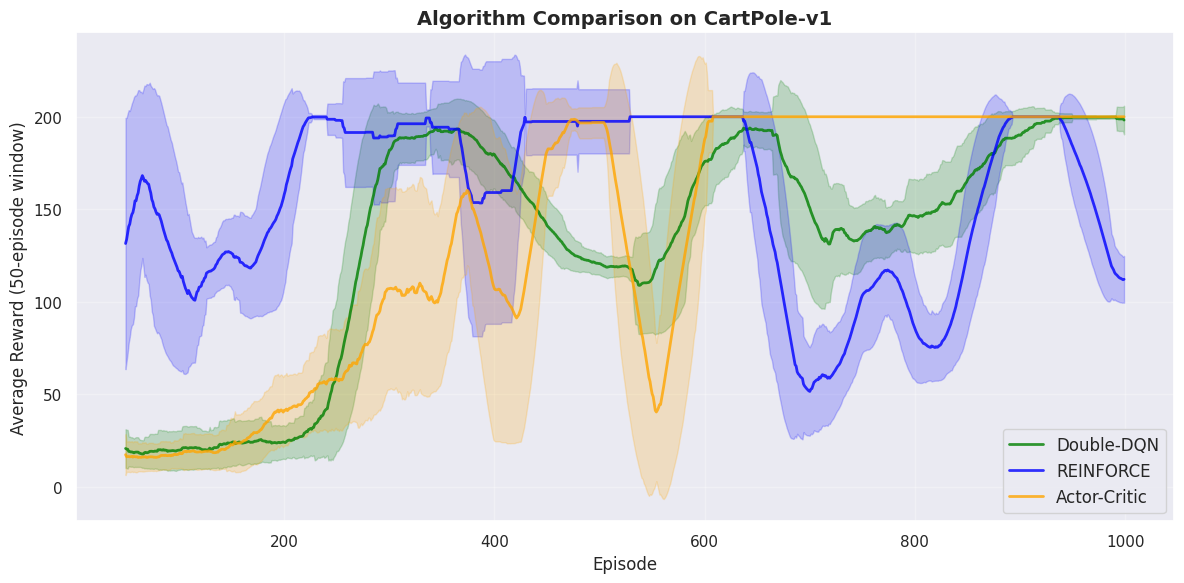


Final Performance on CartPole-v1 (last 100 episodes):
Double-DQN:    198.83 +/- 5.75
REINFORCE:     148.77 +/- 42.19
Actor-Critic:  200.00 +/- 0.00


<Figure size 640x480 with 0 Axes>

In [177]:
# Plot CartPole results
ddqn_rewards = np.load('./results/ddqn_cartpole_rewards.npy').tolist()
reinforce_rewards_cartpole = np.load('./results/reinforce_cartpole_rewards.npy').tolist()
ac_rewards_cartpole = np.load('./results/ac_cartpole_rewards.npy').tolist()

plot_comparison(ddqn_rewards, reinforce_rewards_cartpole, ac_rewards_cartpole, "CartPole-v1")

## Results: Acrobot Comparison

In [174]:
# Plot Acrobot results
# plot_comparison(ddqn_rewards_acrobot, reinforce_rewards_acrobot, ac_rewards_acrobot, "Acrobot-v1")

## Analysis Questions

Answer these questions based on your experimental results:

### CartPole Analysis

**Q1**: Which method converges fastest on CartPole? How many episodes approximately?

**Your answer**: 

**Q2**: Which method shows lowest variance (most stable learning)?

**Your answer**: 

**Q3**: Compare final performance of all three methods. Which achieves highest average reward?

**Your answer**: 

### Acrobot Analysis

**Q4**: Which method works best on Acrobot (harder environment)?

**Your answer**: 

**Q5**: Is Actor-Critic's advantage more pronounced on Acrobot than CartPole? Why?

**Your answer**: 

### Comparative Analysis

**Q6**: How do value-based (DDQN) and policy-based (REINFORCE, Actor-Critic) methods compare overall?

**Your answer**: 

**Q7**: Explain why Actor-Critic outperforms REINFORCE in terms of bias-variance trade-off.

**Your answer**: 

**Q8**: When would you choose policy gradient methods over value-based methods in practice?

**Your answer**: 

## Conclusion

### Key Takeaways

1. **Policy Gradient Methods** optimize policies directly
   - REINFORCE: Simple but high variance
   - Actor-Critic: Lower variance through value function

2. **Comparison Insights**:
   - Value-based (DDQN): Good for discrete actions
   - Policy-based: Better for stochastic policies, continuous actions
   - Actor-Critic: Best of both worlds

3. **Foundations for Advanced RL**:
   - A3C/A2C: Parallel Actor-Critic
   - PPO: Actor-Critic + Trust regions
   - SAC: Actor-Critic + Maximum entropy
   - DDPG/TD3: Actor-Critic for continuous actions